# MNIST Datensatz

Mit Data Augmentation erzeugst du während des Trainings künstliche Variationen deiner Bilder (z. B. leicht gedreht oder gespiegelt). Das Modell lernt so, dass eine "4" auch dann eine "4" bleibt, wenn sie etwas schief steht.

Für "normale" Fotos (z.B. Katzen/Hunde)
- > Bei echten Fotos in deinem eigenen Projekt nutzt man oft zusätzlich:
- >transforms.RandomHorizontalFlip(): Spiegelt das Bild waagerecht.
- >transforms.ColorJitter(brightness=0.2): Verändert leicht die Helligkeit.
- >Profi-Tipp: Nutze das Paket Albumentations, wenn du später sehr komplexe Transformationen für professionelle Projekte brauchst.



In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 1. Setup: Echte MNIST Bilder laden
# Transformation: In Tensor umwandeln und normalisieren
# Erweiterte Pipeline für das Training
# with Data Augmentation
"""
train_transform = transforms.Compose([
    transforms.RandomRotation(15),      # Dreht das Bild zufällig um bis zu 15 Grad
    transforms.RandomAffine(0, scale=(0.9, 1.1)), # Zoomt zufällig rein oder raus (90% bis 110%)
    transforms.ToTensor(),              # Konvertiert zu Tensor & skaliert auf [0, 1]
    transforms.Normalize((0.1307,), (0.3081,)) # Die festen Werte von vorhin
])
"""
# without Data Augmentation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Daten herunterladen (auf die Festplatte im Ordner ./data), only once download, then download=false
#train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_dataset = datasets.MNIST(root='./data', train=True, download=False, transform=transform)
loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Modell anpassen: Input ist jetzt 1*28*28 = 784
model = nn.Sequential(
    nn.Flatten(), 
    nn.Linear(1*28*28, 64),
    nn.ReLU(),
    #nn.Linear(128, 10)
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 10)
)

optimizer = optim.SGD(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

# 2. Training Loop
num_epochs = 4 

for epoch in range(num_epochs):
    print(f"--- Epoch {epoch+1} beginnt ---")
    
    for batch_idx, (data, target) in enumerate(loader):
        if batch_idx==0:
            print("wu: data.shape:", data.shape) #32x1x28x28
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        if batch_idx % 400 == 0:
            print(f"Batch {batch_idx}: Loss = {loss.item():.4f}")

print("\nTraining mit echten MNIST-Daten abgeschlossen!")


--- Epoch 1 beginnt ---
wu: data.shape: torch.Size([32, 1, 28, 28])
Batch 0: Loss = 2.3231
Batch 400: Loss = 0.6230
Batch 800: Loss = 0.3592
Batch 1200: Loss = 0.6166
Batch 1600: Loss = 0.1843
--- Epoch 2 beginnt ---
wu: data.shape: torch.Size([32, 1, 28, 28])
Batch 0: Loss = 0.1625
Batch 400: Loss = 0.3011
Batch 800: Loss = 0.2942
Batch 1200: Loss = 0.2954
Batch 1600: Loss = 0.4265
--- Epoch 3 beginnt ---
wu: data.shape: torch.Size([32, 1, 28, 28])
Batch 0: Loss = 0.2032
Batch 400: Loss = 0.3245
Batch 800: Loss = 0.0653
Batch 1200: Loss = 0.1193
Batch 1600: Loss = 0.1393
--- Epoch 4 beginnt ---
wu: data.shape: torch.Size([32, 1, 28, 28])
Batch 0: Loss = 0.2356
Batch 400: Loss = 0.1385
Batch 800: Loss = 0.1820
Batch 1200: Loss = 0.0678
Batch 1600: Loss = 0.1611

Training mit echten MNIST-Daten abgeschlossen!


# Testdata

In [10]:
# 1. Test-Daten laden (train=False)
# WICHTIG: Die Test-Daten werden NIEMALS "augmentiert" (nur ToTensor & Normalize)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 2. Evaluation
model.eval() # Schaltet Layer wie Dropout/Batchnorm in den Vorhersage-Modus
correct = 0
total = 0

with torch.no_grad(): # Gradienten-Berechnung deaktivieren (spart Speicher & Zeit)
    for data, target in test_loader:
        outputs = model(data)
        
        # Wähle die Klasse mit dem höchsten Wert als Vorhersage
        _, predicted = torch.max(outputs.data, 1)
        
        total += target.size(0)
        correct += (predicted == target).sum().item()

accuracy = 100 * correct / total
print(f"Genauigkeit auf den 10.000 Test-Bildern: {accuracy:.2f}%")




Genauigkeit auf den 10.000 Test-Bildern: 95.67%


<Figure size 1000x800 with 0 Axes>

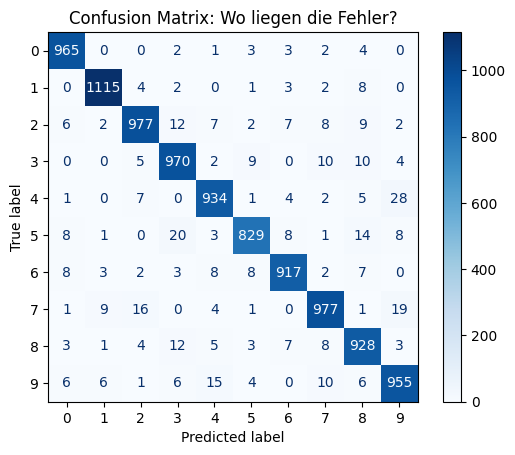

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Vorhersagen sammeln
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for data, target in test_loader:
        outputs = model(data)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.numpy())
        all_labels.extend(target.numpy())

# 2. Matrix berechnen
cm = confusion_matrix(all_labels, all_preds)

# 3. Visualisierung
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Wo liegen die Fehler?")
plt.show()
